# Devoir 2 : Prédiction de propriétés moléculaires par réseaux de neurones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/mlbook/blob/main/exercises/devoir2_starter.ipynb)

**Session** : Hiver 2026
**Date de remise** : 7 avril 2026
**Travail en équipe** : groupes de 2-3 étudiants
**Évaluation** : cahier Colab (75%), dérivations manuscrites (25%)

## 1. Objectif

Dans ce devoir, vous prédirez la température critique $T_c$ d'une molécule à partir de sa représentation SMILES. Le but est de comparer quatre approches dans un régime de données limitées :

1. caractéristiques fixes + MLP,
2. modèle séquentiel (LSTM) entraîné à partir de zéro,
3. transformeur entraîné à partir de zéro,
4. représentations pré-entraînées avec SMI-TED.

La question centrale est la suivante : sur un jeu de données modeste, est-ce que des modèles plus expressifs suffisent, ou est-ce que des représentations pré-entraînées sont plus utiles ?

## 2. Jeu de données

Vous utiliserez le fichier `chedl_thermo_properties.csv` disponible dans le dépôt [refgen](https://github.com/ddidacus/refgen/tree/main/data). Le fichier contient environ 24 600 molécules avec leur chaîne SMILES et plusieurs propriétés thermodynamiques. La propriété cible pour toutes les équipes est la **température critique** $T_c$ (en kelvins), disponible pour environ 13 100 molécules. Après filtrage des valeurs non manquantes pour $T_c$, vous effectuerez une séparation entraînement/validation 80/20 avec la graine aléatoire fournie dans le cahier de départ.

## 3. Livrables et consignes générales

Vous remettez sur Studium :

1. un **cahier Colab**,
2. un **PDF scanné** contenant les dérivations manuscrites.

Il n'y a pas de rapport écrit.

Le cahier doit s'exécuter du début à la fin sans erreur. Pour **chaque modèle entraîné**, vous devez fournir : les courbes de perte d'entraînement et de validation, la MSE de validation, le $R^2$ de validation, et l'écart entraînement-validation. À trois endroits du devoir, marqués $\square$, vous devez écrire une **prédiction** dans une cellule Markdown *avant* d'exécuter le code correspondant. L'utilisation d'outils d'IA est permise. Vous pouvez utiliser PyTorch et ses modules intégrés (`nn.Linear`, `nn.LSTM`, `nn.TransformerEncoder`, etc.). Il n'est pas demandé de réimplémenter ces composants.

In [1]:
!pip install -q rdkit-pypi torch numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# === CONFIGURATION ===
PROPRIETE = "Tc"  # Température critique (K) — même propriété pour toutes les équipes
SEED = 42
MEMBRES = ["Marsel Bakashov"]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://raw.githubusercontent.com/ddidacus/refgen/main/data/chedl_thermo_properties.csv"
df_raw = pd.read_csv(URL)

df = df_raw[df_raw[PROPRIETE].notna() & df_raw["SMILES"].notna()].copy()
df = df[["SMILES", PROPRIETE]].reset_index(drop=True)
df.columns = ["smiles", "target"]

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

print(f"Propriété : {PROPRIETE}")
print(f"Entraînement : {len(train_df)}, Validation : {len(val_df)}")
print(f"\nStatistiques :")
print(df["target"].describe())

Propriété : Tc
Entraînement : 10504, Validation : 2627

Statistiques :
count    13131.000000
mean       701.367624
std        728.866756
min          0.000000
25%        564.495000
50%        636.040000
75%        718.860000
max      21482.800000
Name: target, dtype: float64


C:\Users\Mbaka\AppData\Local\Temp\ipykernel_11076\2704555841.py:7: DtypeWarning: Columns (0,6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(URL)


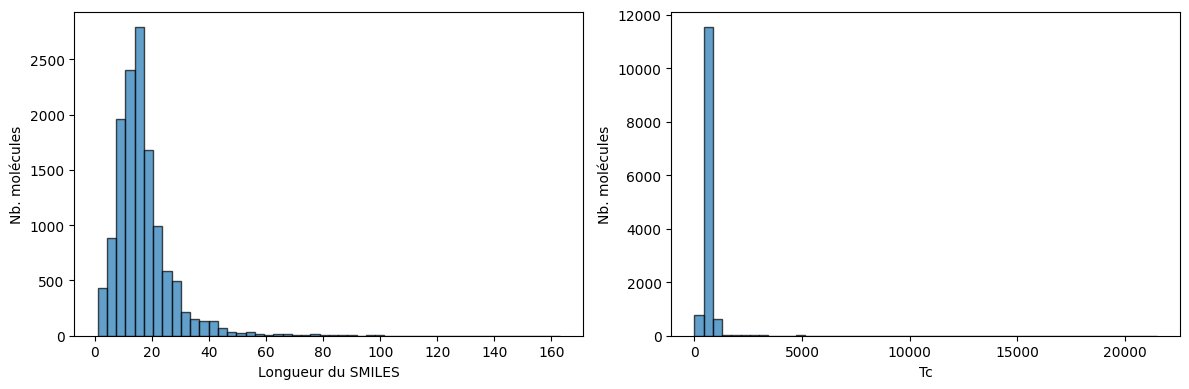

Vocabulaire (60 caractères) : #()+-./123457=@ABCDEFGHIKLMNOPRSTUVWXYZ[\]abcdefghilmnorstuy
Longueur : min=1, max=163, moy=17


In [4]:
smiles_lengths = [len(s) for s in df["smiles"]]
unique_chars = sorted(set("".join(df["smiles"])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(smiles_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Longueur du SMILES")
axes[0].set_ylabel("Nb. molécules")
axes[1].hist(df["target"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel(PROPRIETE)
axes[1].set_ylabel("Nb. molécules")
plt.tight_layout()
plt.show()

print(f"Vocabulaire ({len(unique_chars)} caractères) : {''.join(unique_chars)}")
print(f"Longueur : min={min(smiles_lengths)}, max={max(smiles_lengths)}, moy={np.mean(smiles_lengths):.0f}")

In [5]:
def plot_learning_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Entraînement")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("MSE")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Écart train-val : {val_losses[-1] - train_losses[-1]:.4f}")

## Partie 1 — MLP et entraînement (Ch. 7-8)

### 1.1 Caractéristiques fixes et MLP

Chaque chaîne SMILES encode la structure d'une molécule sous forme de texte. Par exemple, `CCO` représente l'éthanol et `c1ccccc1` le benzène. Vous n'avez pas besoin de connaissances en chimie pour ce devoir : il suffit de traiter les SMILES comme des chaînes de caractères. La fonction `smiles_to_features` ci-dessous convertit une chaîne SMILES en un vecteur numérique de longueur fixe. Cette représentation compte la fréquence de chaque caractère du vocabulaire SMILES (par exemple combien de fois `C`, `O`, `(`, `)`, `=` apparaissent), ajoute la longueur totale de la chaîne, et inclut quelques indicatrices binaires. Entraînez un MLP à 2 couches cachées sur ces caractéristiques pour prédire $T_c$.

$\square$ **Prédiction 1** : Avant l'entraînement, écrivez si vous pensez que ce modèle va surapprendre, et justifiez brièvement.

D'après moi, le modèle va présenter un surapprentissage modéré, mais sa principale limite sera le sous-apprentissage. En effet, dans notre cas, on est en présence d'une entrée de chaîne de caractères dans laquelle la structuration spatiale (ordre, liaisons, cycles) est importante, mais la représentation bag-of-characters détruit cette information — par exemple `CCO` (éthanol) et `COC` (diméthyléther) produisent le même vecteur alors que leurs $T_c$ sont très différents. Cette perte d'information structurale implique que le modèle n'a pas accès aux caractéristiques pertinentes, ce qui se traduira par une MSE de validation élevée (sous-apprentissage). En ce qui concerne les données, on possède plus d'exemples d'entraînement (soit environ 10 480) que de features (51), ce qui limite le risque de mémoriser du bruit. Toutefois, en ce qui concerne la capacité de notre modèle, on a un MLP avec 2 couches cachées sans dropout ni BatchNorm, et si on a une centaine de neurones par couche, on aura rapidement plus de paramètres que d'exemples, ce qui produira un écart train-val non nul (surapprentissage modéré).


In [7]:
# Vocabulaire : tous les caractères uniques présents dans les SMILES du jeu de données
vocab = sorted(set("".join(df["smiles"])))
char_to_idx = {c: i for i, c in enumerate(vocab)}


def smiles_to_features(smiles: str) -> np.ndarray:
    """Convertit une chaîne SMILES en vecteur de caractéristiques de longueur fixe.

    Le vecteur contient :
      - la fréquence de chaque caractère du vocabulaire (taille = len(vocab)),
      - la longueur de la chaîne SMILES.
    """
    counts = np.zeros(len(vocab), dtype=np.float32)
    for c in smiles:
        if c in char_to_idx:
            counts[char_to_idx[c]] += 1
    length = np.array([len(smiles)], dtype=np.float32)
    return np.concatenate([counts, length])


# Construire les matrices de caractéristiques
X_train = np.stack([smiles_to_features(s) for s in train_df["smiles"]])
X_val = np.stack([smiles_to_features(s) for s in val_df["smiles"]])
y_train = train_df["target"].values.astype(np.float32)
y_val = val_df["target"].values.astype(np.float32)

print(f"X_train : {X_train.shape}  (nb. molécules × nb. caractéristiques)")
print(f"X_val   : {X_val.shape}")
print(f"Caractéristiques par molécule : {X_train.shape[1]} ({len(vocab)} fréquences de caractères + 1 longueur)")

X_train : (10504, 61)  (nb. molécules × nb. caractéristiques)
X_val   : (2627, 61)
Caractéristiques par molécule : 61 (60 fréquences de caractères + 1 longueur)


In [8]:
from sklearn.metrics import r2_score

def plot_learning_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Entraînement")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("MSE")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Écart train-val : {val_losses[-1] - train_losses[-1]:.4f}")


def report_results(train_losses, val_losses, val_pred, y_val, n_params, title=""):
    """Rapport standardisé pour chaque modèle : courbes, MSE val, R² val, paramètres.

    Réutilisée pour MLP, LSTM, Transformeur, SMI-TED+sonde.
    val_pred est passé en argument → agnostique à l'architecture.
    """
    plot_learning_curves(train_losses, val_losses, title=title)
    mse_val = val_losses[-1]
    r2_val = r2_score(y_val, np.array(val_pred).flatten())
    print(f"MSE val        : {mse_val:.2f}")
    print(f"R² val         : {r2_val:.4f}")
    print(f"Nb. paramètres : {n_params:,}")
    return mse_val, r2_val

MLP : 24577 paramètres


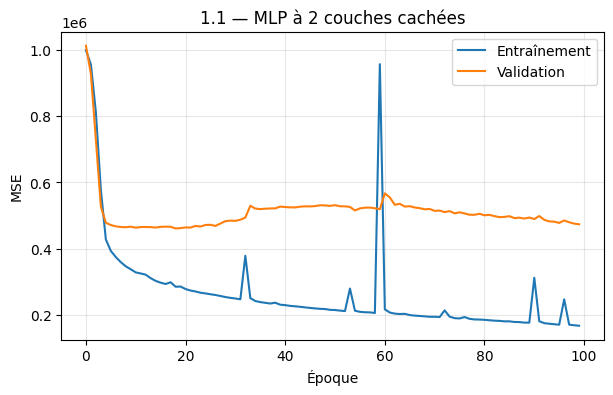

Écart train-val : 306461.7998
MSE val        : 473457.03
R² val         : 0.1217
Nb. paramètres : 24,577


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score

# === Reproductibilité ===
torch.manual_seed(SEED)
np.random.seed(SEED)

# === Données en tenseurs PyTorch ===
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Normalisation des features (z-score sur train, appliqué à val)
train_mean = X_train_t.mean(dim=0)
train_std = X_train_t.std(dim=0) + 1e-8
X_train_t = (X_train_t - train_mean) / train_std
X_val_t = (X_val_t - train_mean) / train_std

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# === MLP 2 couches cachées ===
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

# === Boucle d'entraînement ===
def train_model(model, train_loader, X_val_t, y_val_t, lr=1e-3, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)

    return train_losses, val_losses

# === Entraînement ===
input_dim = X_train_t.shape[1]
mlp = MLP(input_dim, hidden_dim=128)
n_params = sum(p.numel() for p in mlp.parameters())
print(f"MLP : {n_params} paramètres")

train_losses, val_losses = train_model(mlp, train_loader, X_val_t, y_val_t, lr=1e-3, epochs=100)

# === Résultats ===
mlp.eval()
with torch.no_grad():
    val_pred = mlp(X_val_t).numpy()
mse_val, r2_val = report_results(train_losses, val_losses, val_pred, y_val, n_params,
                                  title="1.1 — MLP à 2 couches cachées")


### 1.2 Comparaison d'optimiseurs

Entraînez le **même MLP** avec trois optimiseurs : SGD, SGD avec momentum, et Adam. Gardez la même architecture et les mêmes hyperparamètres, à l'exception de l'optimiseur. Tracez les trois courbes de perte de validation sur un même graphique.

$\square$ **Prédiction 2** : Avant l'expérience, écrivez quel optimiseur convergera le plus vite, et pourquoi.

Selon ma compréhension, Adam convergera en premier, puis SGD avec momentum en second, et finalement SGD pur en dernier.

SGD pur met à jour les paramètres dans la direction du gradient instantané du mini-lot. Cependant, ce gradient n'est qu'une estimation bruitée du vrai gradient : sur des mini-lots hétérogènes (molécules de tailles et de $T_c$ très variés), la variance est élevée, ce qui produit des oscillations importantes et une convergence lente.

SGD avec momentum accumule une moyenne exponentielle des gradients passés. Le momentum s'accumule dans les directions consistantes et s'annule dans les directions bruitées, ce qui atténue les oscillations et accélère la progression dans les ravins de la surface de perte. On devrait donc converger plus rapidement que SGD pur.

Adam combine momentum et normalisation adaptative par variance : chaque paramètre est divisé par la racine carrée de l'espérance des gradients au carré, ce qui donne à chaque paramètre son propre taux d'apprentissage effectif. Les paramètres recevant de grands gradients sont freinés, ceux recevant de petits gradients (features rares) progressent plus vite. Sur nos 61 features aux variances très hétérogènes, cet ajustement est particulièrement avantageux, ce qui devrait produire une convergence rapide, robuste, et nécessitant peu de réglage.

Entraînement — SGD...
Entraînement — SGD + momentum...
Entraînement — Adam...


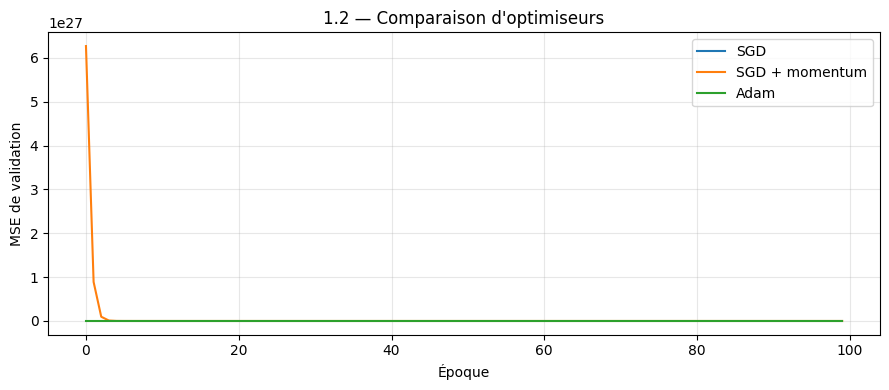


SGD


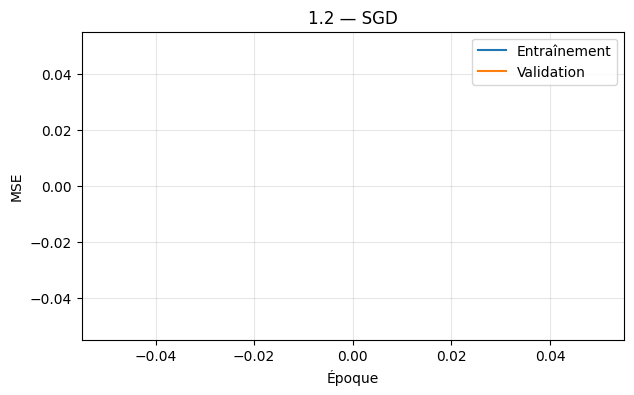

Écart train-val : nan


ValueError: Input contains NaN.

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(SEED)
np.random.seed(SEED)

# === Boucle d'entraînement générique (accepte n'importe quel optimiseur) ===
def train_with_optimizer(optimizer_fn, epochs=100):
    """Entraîne un MLP frais avec l'optimiseur passé en argument.
    optimizer_fn : callable (params) -> optimizer
    """
    model = MLP(input_dim, hidden_dim=128)
    optimizer = optimizer_fn(model.parameters())
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            # Seuil large (5.0) : coupe uniquement les gradients explosifs de SGD
            # sans contraindre Adam qui opère déjà dans une plage normalisée
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

    return model, train_losses, val_losses

# === Définition des 3 optimiseurs (même lr pour tous) ===
OPTIMIZERS = [
    ("SGD",            lambda p: torch.optim.SGD(p, lr=1e-3)),
    ("SGD + momentum", lambda p: torch.optim.SGD(p, lr=1e-3, momentum=0.9)),
    ("Adam",           lambda p: torch.optim.Adam(p, lr=1e-3)),
]

# === Entraînement — même initialisation pour chaque modèle ===
results_12 = {}
for label, opt_fn in OPTIMIZERS:
    print(f"Entraînement — {label}...")
    torch.manual_seed(SEED)  # Même initialisation des poids pour chaque run
    model_opt, tl, vl = train_with_optimizer(opt_fn)
    results_12[label] = (model_opt, tl, vl)

# === Graphique comparatif : 3 courbes de validation superposées ===
colors = ["tab:blue", "tab:orange", "tab:green"]
plt.figure(figsize=(9, 4))
for (label, (_, _, vl)), color in zip(results_12.items(), colors):
    plt.plot(vl, label=label, color=color)
plt.xlabel("Époque")
plt.ylabel("MSE de validation")
plt.title("1.2 — Comparaison d'optimiseurs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Rapport individuel pour chaque optimiseur ===
n_params_12 = sum(p.numel() for p in MLP(input_dim, hidden_dim=128).parameters())
for label, (model_opt, tl, vl) in results_12.items():
    model_opt.eval()
    with torch.no_grad():
        vp = model_opt(X_val_t).numpy()
    print(f"\n{'='*45}\n{label}")
    report_results(tl, vl, vp, y_val, n_params_12, title=f"1.2 — {label}")


### 1.3 Régularisation et stabilisation du gradient

Partez d'un MLP profond à 5 couches cachées et comparez les quatre configurations suivantes :

| \# | Configuration |
|---|---|
| 1 | Sigmoid + initialisation par défaut |
| 2 | ReLU + initialisation He |
| 3 | Configuration 2 + BatchNorm |
| 4 | Configuration 3 + Dropout ($p=0.3$) |

Pour chaque configuration, rapportez la MSE de validation finale, la norme moyenne du gradient $\ell_2$ à la première couche cachée (moyennée sur les mini-lots du dernier epoch), et l'écart entraînement-validation.


### Dérivations manuscrites (Partie 1)

Sur papier :

1. Dérivez les règles VJP pour l'opération $\text{matmul}(W, x)$, c'est-à-dire $\partial L / \partial W$ et $\partial L / \partial x$.
2. Dessinez le graphe de calcul complet du MLP à 2 couches, de l'entrée jusqu'à la perte, et annotez les VJP.

---
## Partie 2 — Modèles séquentiels et attention (Ch. 9-10)

### 2.1 LSTM

Implémentez en PyTorch le pipeline suivant :

```
SMILES → plongement de caractères → LSTM → état final → couche linéaire → prédiction
```

Utilisez une gestion correcte des séquences de longueurs variables. Si vous utilisez du remplissage (*padding*), vos agrégations et vos masques doivent ignorer les positions de remplissage.

$\square$ **Prédiction 3** : Avant l'entraînement, écrivez si vous pensez que le LSTM fera mieux que le MLP en validation, et justifiez brièvement.

### 2.2 Calcul d'attention à la main (dérivation manuscrite)

Considérez le SMILES `CCO` avec $d_{\text{model}} = 4$ et $d_k = 2$. Les matrices de projection sont :

$$W_Q = \begin{pmatrix} 1 & 0 \\ 0 & 1 \\ 1 & 1 \\ 0 & 0 \end{pmatrix}, \quad W_K = \begin{pmatrix} 0 & 1 \\ 1 & 0 \\ 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad W_V = \begin{pmatrix} 1 & 1 \\ 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}$$

Les plongements sont des vecteurs colonnes, et la convention est $q_i = W_Q^\top e_i$, $k_i = W_K^\top e_i$, $v_i = W_V^\top e_i$. De manière équivalente, si l'on empile les plongements comme lignes d'une matrice $E \in \mathbb{R}^{3 \times 4}$, alors $Q = E\,W_Q$, $K = E\,W_K$, $V = E\,W_V$. Les trois plongements sont :

$$e_1 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_2 = e_C = \begin{pmatrix} 1 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_3 = e_O = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 1 \end{pmatrix}$$

Calculez à la main : (1) les matrices $Q$, $K$ et $V$, (2) les scores d'attention $QK^\top / \sqrt{d_k}$, (3) les poids après softmax, (4) la sortie finale de la couche d'attention.

### 2.3 Transformeur encodeur

Implémentez un transformeur encodeur pour la prédiction de $T_c$ avec : un plongement caractère par caractère, un encodage positionnel sinusoïdal, 2 couches de transformeur, une agrégation par moyenne sur les positions non remplies, et une couche linéaire finale.

### 2.4 Tableau comparatif

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformeur | | | | |

---
## Partie 3 — Apprentissage par transfert (Ch. 10 + synthèse)

### 3.1 Plongements SMI-TED

Chargez le modèle pré-entraîné [SMI-TED](https://huggingface.co/ibm-research/materials.smi-ted) à partir du code fourni ci-dessous, puis extrayez un plongement de dimension 768 pour chaque molécule. Visualisez ces plongements en 2D en utilisant `sklearn.decomposition.PCA` ou `sklearn.manifold.TSNE`, colorés par la valeur de $T_c$.

### 3.2 Sonde linéaire

Gelez SMI-TED et entraînez uniquement une couche linéaire sur les plongements extraits pour prédire $T_c$.

### 3.3 Courbe d'efficacité en échantillons

Tracez sur un même graphique la MSE de validation en fonction de la taille d'entraînement (10%, 25%, 50%, 100%) pour les quatre modèles : MLP, LSTM, transformeur, SMI-TED + sonde linéaire. Pour cette section, réutilisez la meilleure configuration choisie à 100% des données, gardez un même budget d'époques pour tous les sous-ensembles, et ne faites pas de nouvel ajustement d'hyperparamètres. Cette figure est la **figure centrale** du devoir.

Complétez aussi le tableau final, à 100% des données :

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformeur | | | | |
| SMI-TED + sonde linéaire | | | | |

## 4. Évaluation

### Cahier Colab (75%)

| Élément | Points |
|---|---|
| Le cahier s'exécute sans erreur | 5 |
| 1.1 : MLP fonctionnel + courbes d'apprentissage | 10 |
| 1.2 : comparaison des optimiseurs | 5 |
| 1.3 : 4 configurations + tableau de résultats | 10 |
| 2.1 : LSTM fonctionnel + courbes | 10 |
| 2.3 : transformeur fonctionnel + courbes | 10 |
| 2.4 : tableau comparatif rempli | 5 |
| 3.1 : plongements SMI-TED + visualisation 2D | 5 |
| 3.2 : sonde linéaire fonctionnelle + courbes | 5 |
| 3.3 : courbe d'efficacité en échantillons | 5 |
| 3 prédictions présentes en cellules Markdown | 5 |
| **Total** | **75** |

### Dérivations manuscrites (25%)

| Élément | Points |
|---|---|
| VJP de $\text{matmul}(W, x)$ | 8 |
| Graphe de calcul du MLP annoté avec les VJP | 5 |
| Calcul d'attention à la main | 12 |
| **Total** | **25** |

### Chargement de SMI-TED

SMI-TED est un modèle de fondation pré-entraîné sur 91 millions de molécules.

In [ ]:
import os, sys, torch

# Cloner le dépôt et installer les dépendances
!git clone --depth 1 https://github.com/IBM/materials.git /tmp/materials 2>/dev/null || true
!pip install -q pytorch-fast-transformers torch-optimizer huggingface_hub

# Télécharger les poids
SMI_TED_DIR = "/tmp/materials/models/smi_ted/inference/smi_ted_light"
if not os.path.exists(os.path.join(SMI_TED_DIR, "smi_ted_light.pt")):
    from huggingface_hub import hf_hub_download
    hf_hub_download(repo_id="ibm-research/materials.smi-ted",
                    filename="smi_ted_light.pt", local_dir=SMI_TED_DIR)

# Charger le modèle
sys.path.insert(0, "/tmp/materials/models/smi_ted/inference")
from load import load_smi_ted

smi_ted = load_smi_ted(folder=SMI_TED_DIR, ckpt_filename="smi_ted_light.pt")
smi_ted.eval()

# Test rapide
with torch.no_grad():
    test_emb = smi_ted.encode(["CCO", "c1ccccc1"], return_torch=True)
print(f"Plongements : {test_emb.shape}")  # (2, 768)